# Статистический анализ показателя *Receipts per Arrival* по странам Европы за 2021 год


In [1]:
!pip install pandas numpy scipy openpyxl matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [2]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 200


## 1. Загрузка файлов


In [5]:
ARRIVALS_FILE = "../data/UN_Tourism_inbound_arrivals_12_2025.xlsx"
EXPENDITURE_FILE = "../data/UN_Tourism_inbound_expenditure_12_2025.xlsx"

if IN_COLAB:
    need_upload = not (Path(ARRIVALS_FILE).exists() and Path(EXPENDITURE_FILE).exists())
    if need_upload:
        print("Загрузите два Excel-файла UN Tourism.")
        uploaded = files.upload()

print("Файл по прибытиям найден:", Path(ARRIVALS_FILE).exists())
print("Файл по поступлениям найден:", Path(EXPENDITURE_FILE).exists())


Файл по прибытиям найден: True
Файл по поступлениям найден: True


## 2. Чтение и подготовка данных


In [6]:
arr_df = pd.read_excel(ARRIVALS_FILE, sheet_name="Data")
exp_df = pd.read_excel(EXPENDITURE_FILE, sheet_name="Data")

EUROPE_COUNTRIES = [
    "Albania", "Andorra", "Armenia", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus", "Czechia",
    "Denmark", "Estonia", "France", "Georgia", "Germany", "Greece",
    "Hungary", "Iceland", "Italy", "Latvia", "Lithuania", "Luxembourg",
    "Malta", "Montenegro", "Netherlands (Kingdom of the)", "North Macedonia",
    "Norway", "Poland", "Portugal", "Republic of Moldova", "Romania",
    "San Marino", "Serbia", "Slovenia", "Spain", "Sweden", "Switzerland",
    "Türkiye", "Ukraine", "United Kingdom of Great Britain and Northern Ireland"
]

COUNTRY_RU = {
    "Albania": "Албания",
    "Andorra": "Андорра",
    "Armenia": "Армения",
    "Austria": "Австрия",
    "Belarus": "Беларусь",
    "Belgium": "Бельгия",
    "Bosnia and Herzegovina": "Босния и Герцеговина",
    "Bulgaria": "Болгария",
    "Croatia": "Хорватия",
    "Cyprus": "Кипр",
    "Czechia": "Чехия",
    "Denmark": "Дания",
    "Estonia": "Эстония",
    "France": "Франция",
    "Georgia": "Грузия",
    "Germany": "Германия",
    "Greece": "Греция",
    "Hungary": "Венгрия",
    "Iceland": "Исландия",
    "Italy": "Италия",
    "Latvia": "Латвия",
    "Lithuania": "Литва",
    "Luxembourg": "Люксембург",
    "Malta": "Мальта",
    "Montenegro": "Черногория",
    "Netherlands (Kingdom of the)": "Нидерланды",
    "North Macedonia": "Северная Македония",
    "Norway": "Норвегия",
    "Poland": "Польша",
    "Portugal": "Португалия",
    "Republic of Moldova": "Молдова",
    "Romania": "Румыния",
    "San Marino": "Сан-Марино",
    "Serbia": "Сербия",
    "Slovenia": "Словения",
    "Spain": "Испания",
    "Sweden": "Швеция",
    "Switzerland": "Швейцария",
    "Türkiye": "Турция",
    "Ukraine": "Украина",
    "United Kingdom of Great Britain and Northern Ireland": "Великобритания",
}

def build_receipts_dataset(year: int) -> pd.DataFrame:
    arrivals = arr_df[
        (arr_df["year"] == year)
        & (arr_df["indicator_label"] == "inbound - trips - total - total - overnight visitors (tourists)")
        & (arr_df["reporter_area_label"].isin(EUROPE_COUNTRIES))
    ][["reporter_area_label", "value"]].rename(columns={"value": "arrivals_thousand"})

    expenditure = exp_df[
        (exp_df["year"] == year)
        & (exp_df["indicator_label"] == "inbound - expenditure - balance of payments - total - visitors")
        & (exp_df["reporter_area_label"].isin(EUROPE_COUNTRIES))
    ][["reporter_area_label", "value"]].rename(columns={"value": "expenditure_musd"})

    data = arrivals.merge(expenditure, on="reporter_area_label", how="inner")
    data["receipts_per_arrival_usd"] = data["expenditure_musd"] / data["arrivals_thousand"] * 1000
    data = data.rename(columns={"reporter_area_label": "country"})
    data["country_ru"] = data["country"].map(COUNTRY_RU)
    data = data.sort_values("country_ru").reset_index(drop=True)
    return data

df_2021 = build_receipts_dataset(2021)
df_2019 = build_receipts_dataset(2019)

print("Размер выборки за 2021 год:", len(df_2021))
df_2021.head()


Размер выборки за 2021 год: 41


,country,arrivals_thousand,expenditure_musd,receipts_per_arrival_usd,country_ru
0,Austria,12728.0,11944.468544,938.440332,Австрия
1,Albania,5515.0,2479.950546,449.673716,Албания
2,Andorra,1949.0,1924.879674,987.624255,Андорра
3,Armenia,876.0,813.427196,928.569859,Армения
4,Belarus,787.0,661.529396,840.571025,Беларусь


## 3. Основные числовые характеристики


In [7]:
x = df_2021["receipts_per_arrival_usd"].to_numpy()
n = len(x)

mean_x = x.mean()
median_x = np.median(x)
var_x = x.var(ddof=1)
std_x = x.std(ddof=1)
cv_x = std_x / mean_x * 100
min_x = x.min()
max_x = x.max()
range_x = max_x - min_x
q1 = np.quantile(x, 0.25)
q3 = np.quantile(x, 0.75)
iqr = q3 - q1
high_fence = q3 + 1.5 * iqr

summary_table = pd.DataFrame({
    "Характеристика": [
        "Объем выборки",
        "Минимум, USD",
        "Q1, USD",
        "Медиана, USD",
        "Q3, USD",
        "Максимум, USD",
        "Размах, USD",
        "Среднее, USD",
        "Стандартное отклонение, USD",
        "Дисперсия",
        "Коэффициент вариации, %",
    ],
    "Значение": [
        n, min_x, q1, median_x, q3, max_x, range_x,
        mean_x, std_x, var_x, cv_x
    ]
})

summary_table


,Характеристика,Значение
0,Объем выборки,4.100000e+01
1,"Минимум, USD",3.491065e+02
2,"Q1, USD",9.285699e+02
3,"Медиана, USD",1.109396e+03
4,"Q3, USD",2.025419e+03
5,"Максимум, USD",9.869002e+03
6,"Размах, USD",9.519896e+03
7,"Среднее, USD",1.797492e+03
8,"Стандартное отклонение, USD",1.856369e+03
9,Дисперсия,3.446106e+06


## 4. Проверка гипотезы о логнормальном распределении


In [8]:
y = np.log(x)

mu_hat = y.mean()
sigma_hat = y.std(ddof=1)

# Подгоняем логнормальное распределение с фиксированным loc=0
shape, loc, scale = st.lognorm.fit(x, floc=0)

# Для критерия Пирсона используем 6 интервалов по квантилям,
# чтобы ожидаемые частоты были одинаковыми и не меньше 5.
k = 6
probs = np.linspace(0, 1, k + 1)
edges = st.lognorm.ppf(probs, s=shape, scale=scale, loc=0)
edges[0] = 0
edges[-1] = np.inf

obs = []
exp = []
interval_labels = []

for i in range(k):
    left, right = edges[i], edges[i + 1]
    if i < k - 1:
        observed = ((x >= left) & (x < right)).sum()
        label = f"{left:.2f} - {right:.2f}"
    else:
        observed = (x >= left).sum()
        label = f"свыше {left:.2f}"

    expected_prob = st.lognorm.cdf(right, s=shape, scale=scale, loc=0) - st.lognorm.cdf(left, s=shape, scale=scale, loc=0)
    expected = n * expected_prob

    obs.append(observed)
    exp.append(expected)
    interval_labels.append(label)

chi_components = [((o - e) ** 2) / e for o, e in zip(obs, exp)]
chi_stat = sum(chi_components)
dfree = k - 1 - 2
chi_crit = st.chi2.ppf(0.95, dfree)
p_value = 1 - st.chi2.cdf(chi_stat, dfree)

chi_table = pd.DataFrame({
    "Интервал": interval_labels,
    "Oi": obs,
    "Ei": exp,
    "(Oi-Ei)^2/Ei": chi_components
})

print(f"mu_hat = {mu_hat:.6f}")
print(f"sigma_hat = {sigma_hat:.6f}")
print(f"chi_stat = {chi_stat:.6f}")
print(f"chi_crit = {chi_crit:.6f}")
print(f"p_value = {p_value:.6f}")

chi_table


mu_hat = 7.196526
sigma_hat = 0.712807
chi_stat = 5.682927
chi_crit = 7.814728
p_value = 0.128098


,Интервал,Oi,Ei,(Oi-Ei)^2/Ei
0,0.00 - 675.47,6,6.833333,0.101626
1,675.47 - 985.62,8,6.833333,0.199187
2,985.62 - 1334.79,11,6.833333,2.540650
3,1334.79 - 1807.65,3,6.833333,2.150407
4,1807.65 - 2637.67,8,6.833333,0.199187
5,свыше 2637.67,5,6.833333,0.491870


## 5. Интервальные оценки


In [9]:
alpha = 0.05
tcrit = st.t.ppf(1 - alpha / 2, n - 1)

# Интервал для среднего исходных данных
ci_mean_x = (
    mean_x - tcrit * std_x / math.sqrt(n),
    mean_x + tcrit * std_x / math.sqrt(n),
)

# Интервал для параметра mu логарифмированных данных
ci_mu = (
    mu_hat - tcrit * sigma_hat / math.sqrt(n),
    mu_hat + tcrit * sigma_hat / math.sqrt(n),
)

# Интервал для медианы логнормального распределения
ci_median = (math.exp(ci_mu[0]), math.exp(ci_mu[1]))

# Интервал для дисперсии логарифмов
chi2_low = st.chi2.ppf(alpha / 2, n - 1)
chi2_high = st.chi2.ppf(1 - alpha / 2, n - 1)
ci_var_log = (
    (n - 1) * sigma_hat**2 / chi2_high,
    (n - 1) * sigma_hat**2 / chi2_low,
)

intervals_table = pd.DataFrame({
    "Интервал": [
        "Для среднего исходных данных, USD",
        "Для параметра mu логарифмов",
        "Для медианы логнормального распределения, USD",
        "Для дисперсии логарифмов",
    ],
    "Левая граница": [
        ci_mean_x[0],
        ci_mu[0],
        ci_median[0],
        ci_var_log[0],
    ],
    "Правая граница": [
        ci_mean_x[1],
        ci_mu[1],
        ci_median[1],
        ci_var_log[1],
    ]
})

intervals_table


,Интервал,Левая граница,Правая граница
0,"Для среднего исходных данных, USD",1211.550012,2383.434785
1,Для параметра mu логарифмов,6.971537,7.421516
2,"Для медианы логнормального распределения, USD",1065.859514,1671.565620
3,Для дисперсии логарифмов,0.342487,0.831814


## 6. Дополнительный анализ


In [10]:
# Сравнение с 2019 годом
comparison = df_2021[["country", "country_ru", "receipts_per_arrival_usd"]].merge(
    df_2019[["country", "receipts_per_arrival_usd"]].rename(columns={"receipts_per_arrival_usd": "receipts_per_arrival_2019"}),
    on="country",
    how="inner"
)

comparison["change_abs"] = comparison["receipts_per_arrival_usd"] - comparison["receipts_per_arrival_2019"]
comparison["change_pct"] = comparison["change_abs"] / comparison["receipts_per_arrival_2019"] * 100

comparison_summary = pd.DataFrame({
    "Показатель": [
        "Объем выборки",
        "Среднее значение, USD",
        "Медиана, USD",
        "Стандартное отклонение, USD",
        "Коэффициент вариации, %",
    ],
    "2019": [
        len(comparison),
        comparison["receipts_per_arrival_2019"].mean(),
        comparison["receipts_per_arrival_2019"].median(),
        comparison["receipts_per_arrival_2019"].std(ddof=1),
        comparison["receipts_per_arrival_2019"].std(ddof=1) / comparison["receipts_per_arrival_2019"].mean() * 100,
    ],
    "2021": [
        len(comparison),
        comparison["receipts_per_arrival_usd"].mean(),
        comparison["receipts_per_arrival_usd"].median(),
        comparison["receipts_per_arrival_usd"].std(ddof=1),
        comparison["receipts_per_arrival_usd"].std(ddof=1) / comparison["receipts_per_arrival_usd"].mean() * 100,
    ],
})

comparison_summary


,Показатель,2019,2021
0,Объем выборки,31.000000,31.000000
1,"Среднее значение, USD",1042.471925,1733.444470
2,"Медиана, USD",778.603955,1084.039298
3,"Стандартное отклонение, USD",988.285826,1934.296176
4,"Коэффициент вариации, %",94.802153,111.586856


In [11]:
# Укрупненные подгруппы
SUBREGIONS = {
    "Северная Европа": [
        "Denmark", "Iceland", "Norway", "Sweden",
        "United Kingdom of Great Britain and Northern Ireland",
        "Estonia", "Latvia", "Lithuania"
    ],
    "Западная Европа": [
        "Austria", "Belgium", "France", "Germany",
        "Luxembourg", "Netherlands (Kingdom of the)",
        "Switzerland", "Andorra"
    ],
    "Южная Европа": [
        "Albania", "Bosnia and Herzegovina", "Croatia", "Cyprus",
        "Greece", "Italy", "Malta", "Montenegro", "Portugal",
        "San Marino", "Slovenia", "Spain", "Türkiye"
    ],
    "Восточная и Юго-Восточная Европа": [
        "Armenia", "Belarus", "Bulgaria", "Czechia", "Georgia",
        "Hungary", "North Macedonia", "Poland", "Republic of Moldova",
        "Romania", "Serbia", "Ukraine"
    ],
}

subregion_rows = []
for group_name, countries in SUBREGIONS.items():
    values = df_2021.loc[df_2021["country"].isin(countries), "receipts_per_arrival_usd"]
    subregion_rows.append({
        "Подгруппа": group_name,
        "n": len(values),
        "Среднее, USD": values.mean(),
        "Медиана, USD": values.median(),
        "Минимум, USD": values.min(),
        "Максимум, USD": values.max(),
    })

subregion_table = pd.DataFrame(subregion_rows)
subregion_table


,Подгруппа,n,"Среднее, USD","Медиана, USD","Минимум, USD","Максимум, USD"
0,Северная Европа,8,1922.095682,1580.564155,585.938195,6010.893562
1,Западная Европа,8,2792.510518,2044.460926,918.075624,9869.002403
2,Южная Европа,13,1357.721014,1096.057086,449.673716,3301.177661
3,Восточная и Юго-Восточная Европа,12,1527.497130,986.109070,349.106469,7030.587347


## 7. Построение и сохранение рисунков
Файлы сохраняются в папку `figures`.


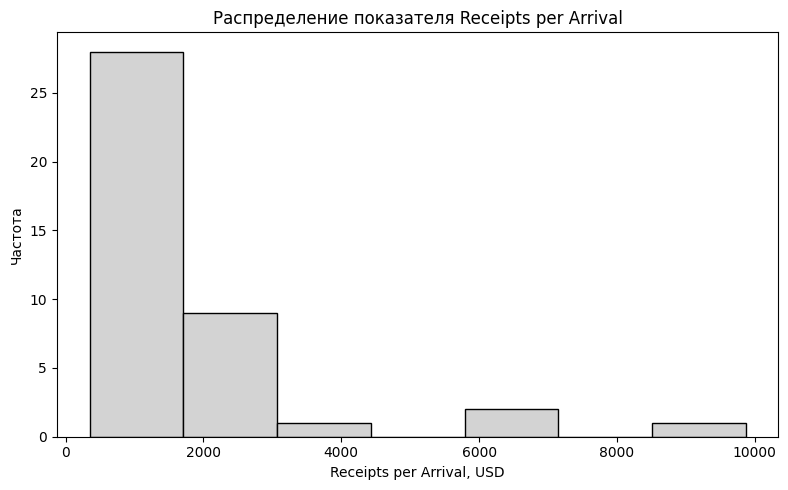

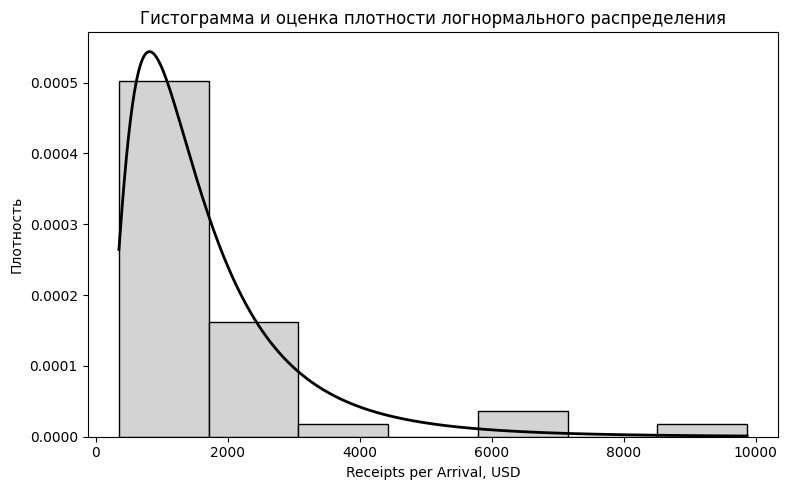

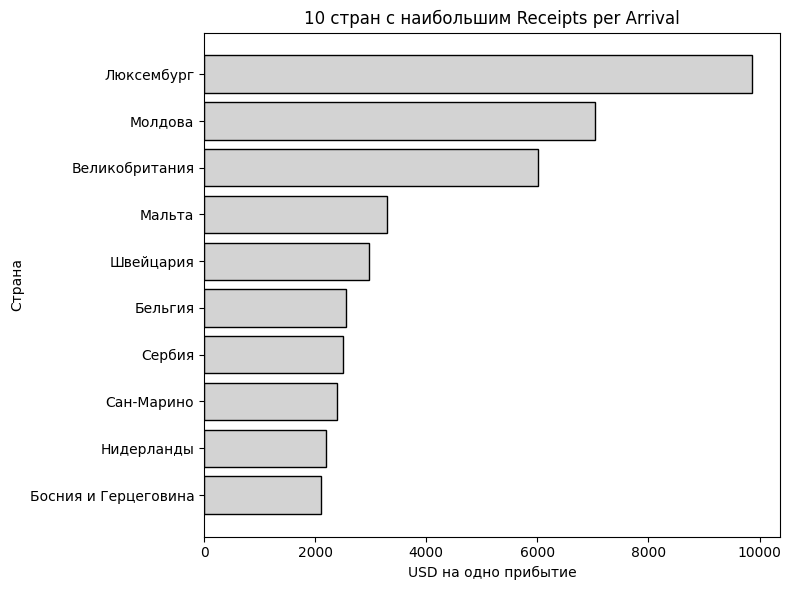

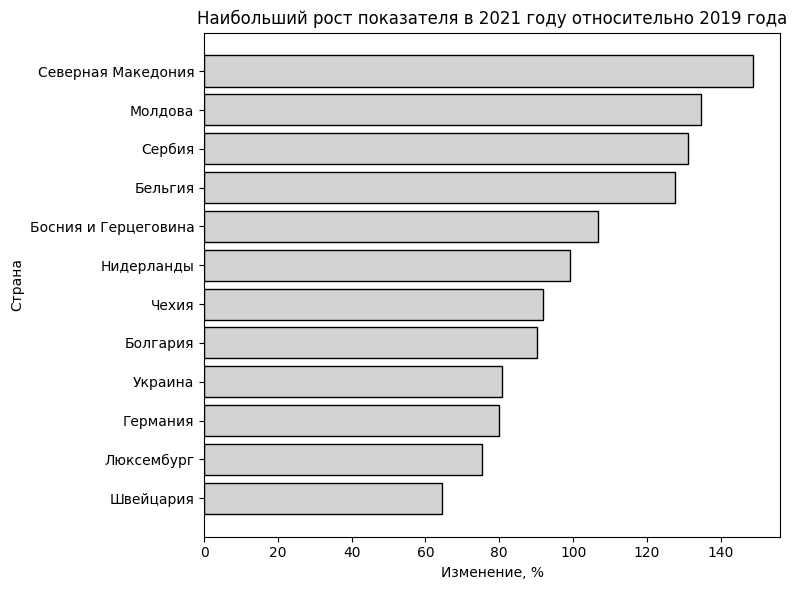

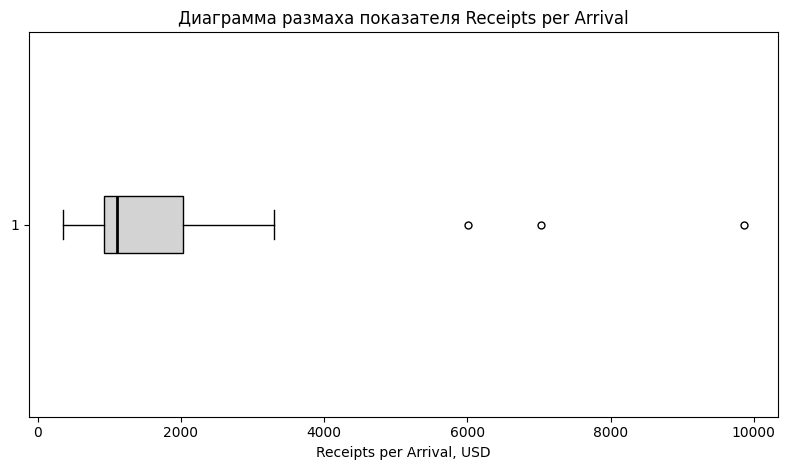

In [15]:
# Сброс возможного темного стиля
plt.style.use("default")

# Глобальные настройки: белый фон, черный текст, черные оси
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "black",
})

# Папка для сохранения графиков
figures_dir = Path("../assets")
figures_dir.mkdir(exist_ok=True)


def style_ax(ax):
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.tick_params(axis="both", colors="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")


# 1. Гистограмма
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.hist(x, bins="sturges", color="lightgray", edgecolor="black")
ax.set_xlabel("Receipts per Arrival, USD")
ax.set_ylabel("Частота")
ax.set_title("Распределение показателя Receipts per Arrival")
style_ax(ax)
plt.tight_layout()
plt.savefig(figures_dir / "histogram_receipts.png", bbox_inches="tight", facecolor="white")
plt.show()

# 2. Гистограмма + логнормальная плотность
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
counts, bins, _ = ax.hist(
    x,
    bins="sturges",
    density=True,
    color="lightgray",
    edgecolor="black"
)
x_grid = np.linspace(x.min(), x.max(), 600)
pdf = st.lognorm.pdf(x_grid, s=shape, scale=scale, loc=0)
ax.plot(x_grid, pdf, color="black", linewidth=2)
ax.set_xlabel("Receipts per Arrival, USD")
ax.set_ylabel("Плотность")
ax.set_title("Гистограмма и оценка плотности логнормального распределения")
style_ax(ax)
plt.tight_layout()
plt.savefig(figures_dir / "histogram_lognormal_fit.png", bbox_inches="tight", facecolor="white")
plt.show()

# 3. Топ-10 стран
top10 = df_2021.nlargest(10, "receipts_per_arrival_usd").sort_values("receipts_per_arrival_usd")

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.barh(
    top10["country_ru"],
    top10["receipts_per_arrival_usd"],
    color="lightgray",
    edgecolor="black"
)
ax.set_xlabel("USD на одно прибытие")
ax.set_ylabel("Страна")
ax.set_title("10 стран с наибольшим Receipts per Arrival")
style_ax(ax)
plt.tight_layout()
plt.savefig(figures_dir / "top10_receipts.png", bbox_inches="tight", facecolor="white")
plt.show()

# 4. Изменение 2019 -> 2021
top_changes = comparison.sort_values("change_pct", ascending=False).head(12).sort_values("change_pct")

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.barh(
    top_changes["country_ru"],
    top_changes["change_pct"],
    color="lightgray",
    edgecolor="black"
)
ax.set_xlabel("Изменение, %")
ax.set_ylabel("Страна")
ax.set_title("Наибольший рост показателя в 2021 году относительно 2019 года")
style_ax(ax)
plt.tight_layout()
plt.savefig(figures_dir / "change_2019_2021.png", bbox_inches="tight", facecolor="white")
plt.show()

# 5. Boxplot
fig, ax = plt.subplots(figsize=(8, 4.8), facecolor="white")
ax.boxplot(
    x,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray", color="black"),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=5)
)
ax.set_xlabel("Receipts per Arrival, USD")
ax.set_title("Диаграмма размаха показателя Receipts per Arrival")
style_ax(ax)
plt.tight_layout()
plt.savefig(figures_dir / "boxplot_receipts.png", bbox_inches="tight", facecolor="white")
plt.show()

## 8. Сохранение таблиц

In [16]:
df_2021.to_csv("receipts_per_arrival_europe_2021.csv", index=False)
comparison.to_csv("receipts_per_arrival_2019_2021_comparison.csv", index=False)
summary_table.to_csv("summary_statistics_2021.csv", index=False)
chi_table.to_csv("chi_square_table.csv", index=False)

print("Файлы сохранены.")
print("Папка с рисунками:", figures_dir.resolve())


Файлы сохранены.
Папка с рисунками: /home/a/Desktop/labs-guap/2course/2term/SPoI/SPoI/lab-1/assets
